In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

24320
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]

Nt: 1024
init. cond.:   0.50   0.50   0.00 




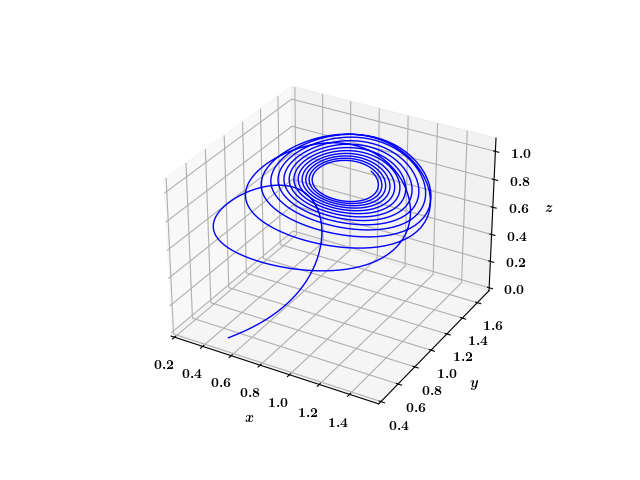

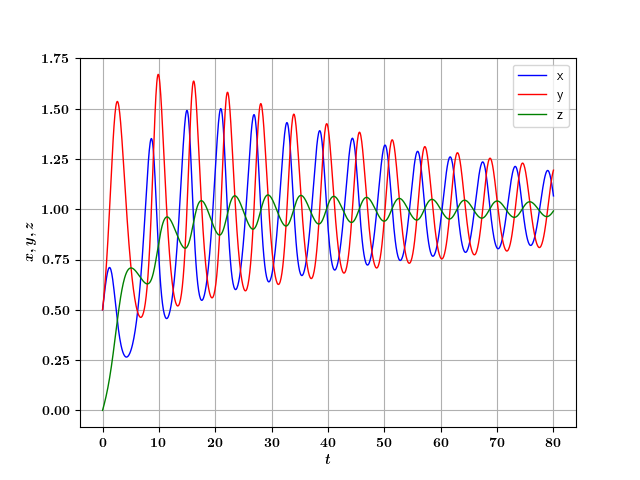

1025


In [67]:
# ---------------------------------------------------------------
# --- Prepare the system: Lotka - Volterra 3D ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 3  # the number of degrees of freedom
    Nx2 = Nx**2 - 1
    F_terms, sys_coefs, return_sys, shift_coefs = None, None, None, None

    # ----------------------------------------------------
    if sel_case == 0:
        x_init = np.array([0.5, 0.5, 0.0])

        tmax, nt = 80, 10
        # aa, eps, eta, coef_re = 1.0, 0.1, 0.2, 10.
        # aa, eps, eta, coef_re = 1., 40., 1., 1.
        # aa, bb, eps, eta, coef_re = 1.0, 0.1, 0.1, 0.2, 10.
        # coef_re = 10.
        # F = [
        #     lambda x:   aa * x[0] - coef_re * bb * x[0] * x[1],
        #     lambda x:   coef_re * eps * x[0] * x[1] - coef_re * eps * x[1] * x[2],
        #     lambda x:   eta * x[1] - eta * x[2] 
        # ]

        aa, bb, eps, eta = 1.0, 1.0, 1., 0.2
        F = [
            lambda x:   aa * x[0] - bb * x[0] * x[1],
            lambda x:   eps * x[0] * x[1] - eps * x[1] * x[2],
            lambda x:   eta * x[1] - eta * x[2] 
        ]


        # --- Construct system matrices ---
        # # *** matrix F) ***
        # F_terms[0][1,0] = - c

        # # *** matrix F1 ***
        # F_terms[1][0,1], F_terms[1][1,0] = a, b

    # ----------------------------------------------------
    if sel_case == 1:
        x_init = np.array([0.5, 0.5])

        tmax, nt = 20, 8
        # tmax, nt = 3, 5

        aa, gg = 1.0, 0.475
        eta_x, eta_y = 1., 1. 
        xi_x, xi_y = 0., 0.

        sys_coefs = {}
        sys_coefs["aa"]    = aa
        sys_coefs["gg"]    = gg
        sys_coefs["eta_x"] = eta_x
        sys_coefs["eta_y"] = eta_y
        sys_coefs["xi_x"]  = xi_x
        sys_coefs["xi_y"]  = xi_y

        def return_sys(ss):
            aa    = ss["aa"]       
            gg    = ss["gg"]    
            eta_x = ss["eta_x"] 
            eta_y = ss["eta_y"] 
            xi_x  = ss["xi_x"]  
            xi_y  = ss["xi_y"]  

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))
            
            F_terms[0][0,0] =   aa * xi_x - eta_y * aa * xi_x * xi_y
            F_terms[0][1,0] = - gg * xi_y + eta_x * gg * xi_x * xi_y

            F_terms[1][0, 0] = aa - eta_y * aa * xi_y
            F_terms[1][0, 1] =    - eta_y * aa * xi_x

            F_terms[1][1, 0] =        eta_x * gg * xi_y
            F_terms[1][1, 1] = - gg + eta_x * gg * xi_x 

            F_terms[2][0, 1] = - eta_y * aa
            F_terms[2][1, 1] =   eta_x * gg
            return F_terms
        
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new
        
        print("\nSystem coefficients:")
        for key, value in sys_coefs.items():
            print("{:s} = {:0.3f}".format(key, value))
        print()

        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0, 0] * x[0] + F_terms[1][0, 1] * x[1] + F_terms[2][0, 1] * x[0] * x[1],
            lambda x: F_terms[0][1,0] + F_terms[1][1, 0] * x[0] + F_terms[1][1, 1] * x[1] + F_terms[2][1, 1] * x[0] * x[1],
        ]

    # ----------------------------------------------------
    return F, tmax, nt, Nx, x_init, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 0

N_nl_orig_ = 2 # formally assume that all considered equations are of the 3-rd order of nonlinearity
F_, tmax_, nt_, Nx_, x_init_ref_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("Nt: {:d}".format(Nt_))
print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

print(len(t_ref_))